# Metrics

> Metric tracking and analysis tools

In [ ]:
#| default_exp metrics

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export

# =================================
# Scientific / numerical
# =================================
import numpy as np
from numpy import trapezoid as trapz
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import RocCurveDisplay, auc

# =================================
# PyTorch
# =================================
from torch import (
    abs,
    argmax,
    complex64,
    div,
    isnan,
    is_tensor,
    isinf,
    real,
    sigmoid,
    where,
    zeros_like,
)
from torch.fft import fft2, fftshift
from torch.nn.functional import one_hot, softmax

# =================================
# fastai
# =================================
from fastai.metrics import *
from fastai.vision.all import AvgMetric, Metric, partial

# =================================
# MONAI
# =================================
import monai.metrics as mm

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import torch_from_numpy

In [ ]:
#| export
def get_metric(metric_cls, backend="monai", *args, **kwargs):
    metric = metric_cls(*args, **kwargs)

    if backend in ("monai", "ignite"):
        # Return MONAI metric as-is
        return metric

    elif backend == "fastai":
        # Wrap for fastai (epoch-level correct version)
        class MonaiFastaiMetric(Metric):
            def reset(self):
                if hasattr(metric, "reset"):
                    metric.reset()

            def accumulate(self, learn):
                pred, targ = learn.pred, learn.y
                metric(pred, targ)

            @property
            def value(self):
                if hasattr(metric, "aggregate"):
                    return metric.aggregate().mean().item()
                else:
                    return None

            @property
            def name(self):
                return metric.__class__.__name__

        return MonaiFastaiMetric()

    else:
        raise ValueError(f"Unknown backend: {backend}")

## Regression metrics

In [ ]:
#| export
SSIMMetric = partial(get_metric, mm.SSIMMetric)
PSNRMetric = partial(get_metric, mm.PSNRMetric)
MSSSIMMetric = partial(get_metric, mm.MultiScaleSSIMMetric)
MAEMetric = partial(get_metric, mm.MAEMetric)
RMSEMetric = partial(get_metric, mm.RMSEMetric)

## Segmentation metrics

In [ ]:
#| export

def DiceMetric(threshold=0.5, instance=False, **kwargs):
    """
    Wrapper around monai.metrics.DiceMetric
    Works for binary segmentation with 1-channel logits.
    Accepts all keyword arguments supported by monai.metrics.DiceMetric
        Example:
            DiceMetric(
                include_background=False,
                reduction="mean",
                get_not_nans=False,
                ignore_empty=True
            )
    """
    dice_metric = mm.DiceMetric(**kwargs)

    def Dice(pred, target):
        # Check shapes 
        if target.ndim == 3:
            target = target.unsqueeze(1)

        # if target is not binary assume it's an instance mask and
        # convert to a binary foreground/background mask
        if instance:
            # Binarize
            pred = (pred > threshold).float()
            target = (target > 0).float()
        else:
            # logits -> probabilities
            pred = sigmoid(pred)
            # Binarize
            pred = (pred > threshold).float()

        dice_metric.reset()
        dice_metric(pred, target)
        return dice_metric.aggregate()

    return AvgMetric(Dice)


In [ ]:
#| export

def PanopticQualityMetric(**kwargs):
    """
    Wrapper around monai.metrics.PanopticQualityMetric.

    Expects:
        pred  : (B, C, H, W) logits
        target: (B, H, W) or (B, 1, H, W) panoptic map
                Each pixel contains encoded panoptic label
                (semantic + instance id).

    All kwargs are forwarded to MONAI PanopticQualityMetric.
    """
    pq_metric = mm.PanopticQualityMetric(**kwargs)

    def PQ(pred, target):
        # Convert logits to discrete labels
        # pred = pred.argmax(dim=1)  # (B, H, W)

        if target.ndim == 4 and target.shape[1] == 1:
            target = target.squeeze(1)

        pq_metric.reset()
        pq_metric(y_pred=pred, y=target)
        return pq_metric.aggregate()

    return AvgMetric(PQ)

## Classification Metrics

In [ ]:
#| export

def ROCAUCMetric(num_classes=None, # if not None, checks if preds and targets are one-hot encoded
                 act=None,         # activation operations, typically Sigmoid or Softmax.
                 **kwargs):
    """
    Wrapper around monai.metrics.ROCAUCMetric.

    If num_classes is None:
        assumes pred and target are already one-hot / probability encoded.

    If num_classes is provided:
        automatically one-hot encodes pred/target when needed.
    """
    rocaucmetric = mm.ROCAUCMetric(**kwargs)

    def _maybe_one_hot(x):
        # already encoded
        if x.ndim > 1 and x.shape[1] == num_classes:
            return x

        return one_hot(x.long(), num_classes=num_classes)

    def ROCAUC(pred, target):
        if act is not None:
            pred = act(pred)

        if num_classes is not None:
            pred = _maybe_one_hot(pred)
            target = _maybe_one_hot(target)

        rocaucmetric.reset()
        rocaucmetric(pred, target)
        return rocaucmetric.aggregate()

    return AvgMetric(ROCAUC)

### ROC Curve

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc


def plot_roc_curve_with_std(
    y_probs_folds,
    y_true_folds,
    n_points=200,
    show_folds=False,
    title="ROC curve with cross-validation"
):
    """
    Plot ROC curves across CV folds with mean ROC and ±1 std band.

    Parameters
    ----------
    y_probs_folds : list of array-like
        Predicted probabilities for the positive class per fold.
    y_true_folds : list of array-like
        Ground truth labels per fold.
    n_points : int
        Resolution of interpolated ROC curve.
    show_folds : bool
        Whether to display individual fold curves.
    title : str
        Plot title.
    """

    fpr_grid = np.linspace(0, 1, n_points)

    tprs = []
    aucs = []

    fig, ax = plt.subplots(figsize=(6, 6))

    # ---------------------------------------------------------------------
    # Per-fold ROC
    # ---------------------------------------------------------------------
    for fold, (y_prob, y_true) in enumerate(zip(y_probs_folds, y_true_folds)):

        roc = RocCurveDisplay.from_predictions(
            y_true,
            y_prob,
            ax=ax,
            curve_kwargs={
                "alpha": 0.25 if show_folds else 0.0,
                "lw": 1
            }
        )

        # Interpolate TPR onto common grid
        tpr_interp = np.interp(fpr_grid, roc.fpr, roc.tpr)
        tpr_interp[0] = 0.0

        tprs.append(tpr_interp)
        aucs.append(roc.roc_auc)

        # Hide legend entries if not requested
        if not show_folds:
            roc.line_.set_label("_nolegend_")

    # ---------------------------------------------------------------------
    # Aggregate statistics
    # ---------------------------------------------------------------------
    tprs = np.array(tprs)

    mean_tpr = tprs.mean(axis=0)
    mean_tpr[-1] = 1.0

    std_tpr = tprs.std(axis=0)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    # ---------------------------------------------------------------------
    # Mean ROC curve
    # ---------------------------------------------------------------------
    ax.plot(
        fpr_grid,
        mean_tpr,
        color="red",
        lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})"
    )

    # ---------------------------------------------------------------------
    # Confidence band
    # ---------------------------------------------------------------------
    ax.fill_between(
        fpr_grid,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        color="grey",
        alpha=0.2,
        label="±1 std. dev."
    )

    # ---------------------------------------------------------------------
    # Final styling
    # ---------------------------------------------------------------------
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")

    plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

In [ ]:
#| export
def plot_roc_curve_with_std_interactive(
    y_probs_folds,
    y_true_folds,
    n_points=200,
    show_folds=True,
    title="ROC curve with cross-validation"
):

    fpr_grid = np.linspace(0, 1, n_points)

    tprs = []
    aucs = []

    fig = go.Figure()

    # ------------------------------------------------------------
    # Per-fold ROC
    # ------------------------------------------------------------
    for i, (y_prob, y_true) in enumerate(zip(y_probs_folds, y_true_folds)):

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0

        tprs.append(tpr_interp)
        aucs.append(roc_auc)

        if show_folds:
            fig.add_trace(go.Scatter(
                x=fpr,
                y=tpr,
                mode="lines",
                name=f"Fold {i+1} (AUC={roc_auc:.2f})",
                opacity=0.4
            ))

    tprs = np.array(tprs)

    # ------------------------------------------------------------
    # Mean + std
    # ------------------------------------------------------------
    mean_tpr = tprs.mean(axis=0)
    mean_tpr[-1] = 1.0

    std_tpr = tprs.std(axis=0)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    upper = np.minimum(mean_tpr + std_tpr, 1)
    lower = np.maximum(mean_tpr - std_tpr, 0)

    # Mean ROC
    fig.add_trace(go.Scatter(
        x=fpr_grid,
        y=mean_tpr,
        mode="lines",
        name=f"Mean ROC (AUC={mean_auc:.2f} ± {std_auc:.2f})",
        line=dict(width=3, color="red")
    ))

    # Std band
    fig.add_trace(go.Scatter(
        x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
        y=np.concatenate([upper, lower[::-1]]),
        fill="toself",
        fillcolor="rgba(128,128,128,0.2)",
        line=dict(color="rgba(255,255,255,0)"),
        hoverinfo="skip",
        name="±1 std. dev."
    ))

    # Chance line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        name="Chance"
    ))

    # ------------------------------------------------------------
    # Styling: black axes + centered title
    # ------------------------------------------------------------
    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,              # center title
            xanchor="center"
        ),
            xaxis=dict(
            range=[0, 1],
            autorange=False,
            title="False Positive Rate",
            showline=True,
            linecolor="black",
            mirror=True,
            ticks="outside",
            scaleanchor="y",
            scaleratio=1
        ),
        yaxis=dict(
            range=[0, 1],
            autorange=False,
            title="True Positive Rate",
            showline=True,
            linecolor="black",
            mirror=True,
            ticks="outside"
        ),
        width=700,
        height=700,
        template="plotly_white",
        legend=dict(orientation="v")
    )

    fig.show()

    return fig

##### Example: plot the ROC curve for the data after applying cross-validation and training in order to visualize the standard deviation to compare between splits.

In [ ]:
from sklearn.svm import SVC

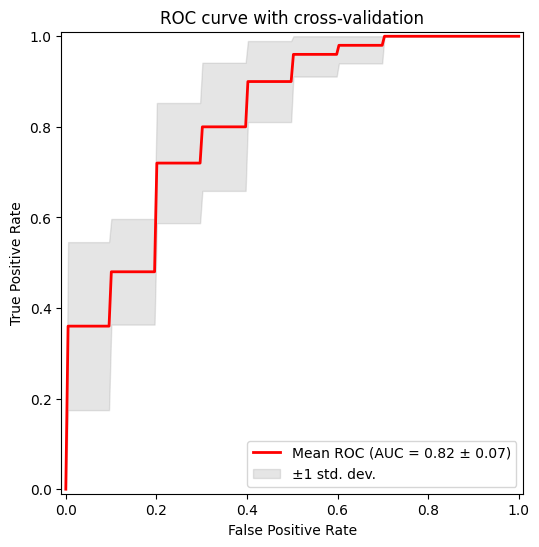

In [ ]:
# -----------------------------------------------------------------------------
# 1. Load and preprocess data
# -----------------------------------------------------------------------------
iris = load_iris()
X, y = iris.data, iris.target

# Keep only two classes (binary classification)
mask = y != 2
X, y = X[mask], y[mask]

n_samples, n_features = X.shape

# -----------------------------------------------------------------------------
# 2. Feature augmentation (noise injection for high-dimensional setting)
# -----------------------------------------------------------------------------
rng = np.random.RandomState(0)
noise = rng.randn(n_samples, 300 * n_features)

X = np.concatenate([X, noise], axis=1)

# -----------------------------------------------------------------------------
# 3. Cross-validation setup
# -----------------------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# -----------------------------------------------------------------------------
# 4. Model
# -----------------------------------------------------------------------------
model = SVC(kernel="linear", probability=True, random_state=0)

# -----------------------------------------------------------------------------
# 5. Cross-validated predictions
# -----------------------------------------------------------------------------
y_probs_folds = []
y_true_folds = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    y_probs_folds.append(probs)
    y_true_folds.append(y_test)

# -----------------------------------------------------------------------------
# 6. Evaluation
# -----------------------------------------------------------------------------
plot_roc_curve_with_std(
    y_probs_folds,
    y_true_folds
)

plot_roc_curve_with_std_interactive(
    y_probs_folds,
    y_true_folds
);

## Metrics Reloaded

**Metrics Reloaded** is a comprehensive recommendation framework designed to help researchers and practitioners in biomedical image analysis select and apply the most appropriate performance metrics for their specific tasks. Traditional validation practices often rely on a few standard metrics (e.g., Dice score, IoU), which might not always reflect the domain-specific interests or characteristics of a particular problem — such as class imbalance, object size, boundary importance, or task type (classification, segmentation, detection). ([Nature][1])

At its core, Metrics Reloaded introduces the concept of a problem fingerprint: a structured representation of properties relevant to metric selection (e.g., whether the problem is semantic segmentation vs. object detection, the importance of boundary accuracy, class prevalence, etc.). Using the problem fingerprint, the framework **guides users through a systematic decision process** to identify a set of suitable metrics that align with both the task and domain interest. ([Nature][1])

Metrics Reloaded supports a broad range of image analysis tasks, including:

* **Image-level classification**
* **Semantic segmentation**
* **Object detection**
* **Instance segmentation**

To make the selection process more accessible, Metrics Reloaded is also available as an **interactive online tool**, where users can explore the framework’s recommendations and walk through the metric selection process based on their problem fingerprint:
[https://metrics-reloaded.dkfz.de/](https://metrics-reloaded.dkfz.de/) — *Metrics Reloaded online tool* ([metrics-reloaded.dkfz.de][2])

This tool provides a user-centric way to explore metric strengths, weaknesses, and recommendations tailored to different imaging tasks and validation challenges.

[1]: https://www.nature.com/articles/s41592-023-02151-z?utm_source=chatgpt.com "Metrics reloaded: recommendations for image analysis validation | Nature Methods"
[2]: https://metrics-reloaded.dkfz.de/?utm_source=chatgpt.com "Metrics Reloaded"


In [ ]:
#| export
def MetricsReloadedBinary(metric_name, **kwargs):
    "Binary pairwise metrics of MetricsReloaded library"
    def MRB(x, y):
        return mm.MetricsReloadedBinary(metric_name, **kwargs)(x,y).mean()
    return AvgMetric(MRB)

def MetricsReloadedCategorical(metric_name, **kwargs):
    "Categorical pairwise metrics of MetricsReloaded library"
    def MRC(x, y):
        return mm.MetricsReloadedCategorical(metric_name, **kwargs)(x,y).mean()
    return AvgMetric(MRC)

## Fourier Ring Correlation

Fourier Ring Correlation (FRC) is a frequency-domain method used to quantify the similarity between two independent measurements of the same underlying signal. It is widely applied in fields such as microscopy, cryo-electron microscopy, and super-resolution imaging to estimate spatial resolution in a statistically robust manner. By comparing corresponding Fourier components over concentric rings (in 2D) or shells (in 3D) of equal spatial frequency, FRC provides a frequency-dependent correlation profile that reflects the reproducibility of structural information.

Mathematically, the Fourier ring correlation at spatial frequency ( r ) is defined as:

$$FRC(r) = \frac{\sum_{k \in r} F_1(k) \overline{F_2(k)}}{\sqrt{\left(\sum_{k \in r} |F_1(k)|^2\right) \left(\sum_{k \in r} |F_2(k)|^2\right)}}$$

where $ F_1(k) $ and $ F_2(k) $ are the Fourier transforms of the two independent images, $ k $ denotes frequency coordinates lying on a ring of radius $ r $, and the overline indicates complex conjugation. The numerator measures cross-correlation of corresponding Fourier coefficients, while the denominator normalizes by their respective spectral energies.

A function that calculates an FRC-based metric determines a resolution criterion by identifying where the FRC curve crosses the predefined threshold at 1/7.

The resulting FRC curve provides a frequency-resolved measure of signal consistency, and the derived cutoff frequency can be converted into a spatial resolution estimate.

#### Radial mask

In [ ]:
#| export

def radial_mask(r,      # Radius of the radial mask
                cx=128, # X coordinate mask center
                cy=128, # Y coordinate maske center
                sx=256, # Size of the x-axis
                sy=256, # Size of the y-axis
                delta=1,# Thickness adjustment for the circular mask
               ):

    """
    Generate a radial mask.

    Returns:
       - numpy.ndarray: Radial mask.
    """
    
    sx = np.arange(0, sx)
    sy = np.arange(0, sy)

    # Calculate squared distances from each point in the grid to the center
    ind = (sx[np.newaxis, :] - cx) ** 2 + (sy[:, np.newaxis] - cy) ** 2

    # Define inner boundary of the circular mask
    ind1 = ind <= ((r[0] + delta) ** 2)

    # Define outer boundary of the circular mask
    ind2 = ind > (r[0] ** 2)

    # Create the radial mask by combining inner and outer boundaries
    return ind1 * ind2


In [ ]:
#| export

def get_radial_masks(width, # Width of the image
                     height, # Height of the image
                     ):

    """
    Generates a set of radial masks and corresponding to spatial frequencies.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: Array of radial masks.
            - numpy.ndarray: Array of spatial frequencies corresponding to the masks.
    """

    # Calculate Nyquist frequency
    freq_nyq = int(np.floor(int(min(width, height)) / 2.0))
   
    # Generate radii from 0 to Nyquist frequency
    radii = np.arange(freq_nyq).reshape(freq_nyq, 1)

    # Generate radial masks using the radial_mask function    
    radial_masks = np.apply_along_axis(radial_mask, 1, radii, width//2, height//2, width, height, 1)

    # Calculate spatial frequencies
    spatial_freq = radii.astype(np.float32) / freq_nyq
    spatial_freq = spatial_freq / max(spatial_freq)
    spatial_freq = spatial_freq.squeeze(1)

    return radial_masks, spatial_freq


#### Fourier ring correlation

In [ ]:
#| export
def get_fourier_ring_correlations(image1, # First input image
                                  image2, # Second input image
                                  ):
  
    """
    Compute Fourier Ring Correlation (FRC) between two images.

    Returns:
        tuple: A tuple containing:
            - torch.Tensor: Fourier Ring Correlation values.
            - torch.Tensor: Array of spatial frequencies.
    """
    

    # Get image height and width
    height = image1.shape[len(image1.shape)-1]
    width = image1.shape[len(image1.shape)-2]
    
    # Get set of radial masks, spatial frequency, and Nyquist frequency
    radial_masks, spatial_frequency = get_radial_masks(height,width)

    # Get Nyquist frequency
    freq_nyq = len(spatial_frequency)
    
    # Transform tensor to complex
    image1 = image1.to(complex64)
    image2 = image2.to(complex64)

    # Transofrm array dimensions to (freq_nyq, width. height)
    image1 = image1.unsqueeze(0).repeat(freq_nyq, 1, 1)
    image2 = image2.unsqueeze(0).repeat(freq_nyq, 1, 1)

    # Convert spatial frequency and radial masks to torch.tensor
    spatial_frequency = torch_from_numpy(spatial_frequency)
    radial_masks = torch_from_numpy(radial_masks)

    # Transform tensor to complex
    radial_masks = radial_masks.to(complex64)
         
    # Compute fourier transform
    fft_image1 = fftshift(fft2(image1))
    fft_image2 = fftshift(fft2(image2))

    # Get elements only in the ring
    t1 = fft_image1 * radial_masks
    t2 = fft_image2 * radial_masks
        
    # image2 to complex conjugate
    t2_conj = t2.conj()

    # Numerator
    numerator = abs(real((t1 * t2_conj).sum(dim=(1,2))))

    # Denominator    
    denominator_1 = ((abs(t1) * abs(t1)).sum(dim=(1,2)))
    denominator_2 = ((abs(t2) * abs(t2)).sum(dim=(1,2)))     
    denominator = sqrt(denominator_1 * denominator_2)
   
    # Fourier shell correlation
    FRC = div(numerator, denominator)

    # Remove possible inf and NaN.
    FRC = where(isinf(FRC), zeros_like(FRC), FRC)  # inf
    FRC = where(isnan(FRC), zeros_like(FRC), FRC)  # NaN

    return FRC , spatial_frequency

In [ ]:
#| export

def FRCMetric(image1, # First input image
              image2, # Second input image
              ):


    """
    Compute the area under the Fourier Ring Correlation (FRC) curve between two images.

    Returns:
        - float: The area under the FRC curve.
    """

    # Calculate the Fourier Ring Correlation and spatial frequency
    FRC, spatial_frequency = get_fourier_ring_correlations(image1, image2)

    # Convert to numpy
    FRC = FRC.numpy()
    spatial_frequency = spatial_frequency.numpy()
      
    # Compute the area under the curve using trapezoidal integration
    area = trapz(FRC, spatial_frequency)
    
    return area


---

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()